In [59]:
import pandas as pd
import numpy as np

In [60]:
A_df = pd.read_csv("data/A.csv", header=None)
B_df = pd.read_csv("data/B.csv", header=None)
C_df = pd.read_csv("data/C.csv", header=None)

# Convert all string-looking numbers to floats
A = A_df.apply(pd.to_numeric, errors='coerce').values
B = B_df.apply(pd.to_numeric, errors='coerce').values
C = C_df.apply(pd.to_numeric, errors='coerce').values

In [61]:
A_index_df = pd.read_csv("data/index_A.csv")
B_index_df = pd.read_csv("data/index_B.csv")
C_index_df = pd.read_csv("data/index_C.csv")

# Remove Transporation

In [62]:
A_transport_df = pd.read_csv("data/Transportation_A.csv")

In [63]:
# create a dict mapping each provider name to all its indices in A_index_df
mapping = A_index_df.groupby('provider name')['index'].apply(list)

# build a single flat list of all matching indices for the foreground processes
matched_indices_transport = [
    idx
    for name in A_transport_df['provider name']
    if name in mapping
    for idx in mapping[name]
]

In [64]:
import numpy as np

# matched_indices_transport is the list of indices to remove
to_drop = np.array(sorted(set(matched_indices_transport), key=int))

# 1) Remove from A_index_df
mask_keep = ~A_index_df['index'].isin(to_drop)
A_index_df = A_index_df.loc[mask_keep].copy()

# 2) Remove corresponding rows and columns from A
A = np.delete(A, to_drop, axis=0)  # remove rows
A = np.delete(A, to_drop, axis=1)  # remove columns

# 3) Remove the same columns from B (keep rows)
B = np.delete(B, to_drop, axis=1)

# 4) Reset the index column in A_index_df
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

# Remove and aggregate Electricity

In [65]:
A_elec_df = pd.read_csv("data/Electricity_A.csv")

In [66]:
# Inputs assumed:
# A : numeric numpy array (rows x cols)
# A_index_df : DataFrame with columns ["index", "provider name", "flow name", ...]
# A_elec_df : DataFrame with column ["provider name"] listing all electricity providers
# The indices in A_index_df["index"] align with both row and column positions of A.

# 0) Build the set of electricity provider names
elec_names = set(A_elec_df['provider name'].dropna().astype(str).unique())

# 1) Find their indices in A_index_df
elec_idx = A_index_df.loc[A_index_df['provider name'].astype(str).isin(elec_names), 'index'].astype(int).unique()

# 2) Locate the mix row index (must exist)
mix_name = "Electricity Mix (Global)"
mix_rows = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int).unique()
if len(mix_rows) == 0:
    raise ValueError("Electricity Mix (Global) not found in A_index_df['provider name'].")
mix_idx = int(mix_rows[0])

# Ensure the mix row is not purged
elec_idx_set = set(map(int, elec_idx))
elec_idx_wo_mix = sorted(elec_idx_set - {mix_idx})

# 3) Aggregate: add all electricity rows (except the mix row) into the mix row, column-wise
if len(elec_idx_wo_mix) > 0:
    # in case of NaNs
    add_block = np.nansum(A[elec_idx_wo_mix, :], axis=0)
    A[mix_idx, :] = np.nan_to_num(A[mix_idx, :]) + np.nan_to_num(add_block)

# 4) Decide what to drop
rows_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity rows except the mix row
cols_to_drop = np.array(elec_idx_wo_mix, dtype=int)            # drop electricity columns except the mix column

# (Optionally also drop the mix COLUMN; keep it if you want to retain that process as a column)
# To ALSO drop the mix column, uncomment the next line:
# cols_to_drop = np.array(sorted(elec_idx_set), dtype=int)

# 5) Remove rows/columns from A and columns from B
if rows_to_drop.size > 0:
    A = np.delete(A, rows_to_drop, axis=0)
if cols_to_drop.size > 0:
    A = np.delete(A, cols_to_drop, axis=1)
    B = np.delete(B, cols_to_drop, axis=1)

# 6) Remove the same rows from A_index_df (only rows; columns in A_index_df are metadata)
if len(elec_idx_wo_mix) > 0:
    keep_mask = ~A_index_df['index'].astype(int).isin(elec_idx_wo_mix)
    A_index_df = A_index_df.loc[keep_mask].copy()

# 7) Reset the "index" column in A_index_df to reflect 0..n-1 after deletions
A_index_df['index'] = np.arange(len(A_index_df), dtype=int)

In [67]:
# 8) Zero specific entries in A for the mix column
mix_name = "Electricity Mix (Global)"
mix_col_idx_s = A_index_df.loc[A_index_df['provider name'] == mix_name, 'index'].astype(int)

if mix_col_idx_s.empty:
    raise ValueError("Mix column not found after pruning. Did you drop the mix column?")
mix_col = int(mix_col_idx_s.iloc[0])

target_names = {"Fossil Electricity", "Clean Electricity"}
row_idxs = (
    A_index_df.loc[A_index_df['provider name'].isin(target_names), 'index']
    .astype(int)
    .to_numpy()
)

if row_idxs.size > 0:
    A[row_idxs, mix_col] = 0.0
else:
    print("Warning: no rows named 'Fossil Electricity' or 'Clean Electricity' found after pruning.")

# Remove Carbon Capture

In [68]:
carbon_capture_decisions_df = pd.read_csv("data/carbon_capture_decisions.csv")

In [69]:
import numpy as np
import pandas as pd

# normalize for reliable matching
ekey = lambda s: str(s).strip().casefold()

# copies + keys
A_index_df = A_index_df.copy()
carbon_capture_decisions_df = carbon_capture_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
carbon_capture_decisions_df["col_key"] = carbon_capture_decisions_df["Provider name"].map(ekey)
carbon_capture_decisions_df["row_key"] = carbon_capture_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices (row/col) in A
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric X
carbon_capture_decisions_df["Linear Economy"] = pd.to_numeric(
    carbon_capture_decisions_df["Linear Economy"], errors="coerce"
)

# apply: for each decision row, A[row, col] *= X
n_pairs = 0
skipped = 0

for _, d in carbon_capture_decisions_df.iterrows():
    X = d["Linear Economy"]
    if pd.isna(X):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(X)
            n_pairs += 1

# Remove Microplastic treatment

In [70]:
microplastics_decisions_df = pd.read_csv("data/microplastics_decisions.csv")

In [71]:
import numpy as np
import pandas as pd

# normalizer
ekey = lambda s: str(s).strip().casefold()

# copies + normalized keys
A_index_df = A_index_df.copy()
microplastics_decisions_df = microplastics_decisions_df.copy()

A_index_df["prov_key"] = A_index_df["provider name"].map(ekey)
microplastics_decisions_df["col_key"] = microplastics_decisions_df["Provider name"].map(ekey)
microplastics_decisions_df["row_key"] = microplastics_decisions_df["Input parameters names"].map(ekey)

# provider key -> list of integer indices in A (rows/cols)
idx_map = (
    A_index_df.groupby("prov_key")["index"]
    .apply(lambda s: list(map(int, s)))
    .to_dict()
)

# ensure numeric decision value
microplastics_decisions_df["No WWT Filtration"] = pd.to_numeric(
    microplastics_decisions_df["No WWT Filtration"], errors="coerce"
)

# apply decisions: A[row, col] *= value
n_pairs = 0
skipped = 0

for _, d in microplastics_decisions_df.iterrows():
    x = d["No WWT Filtration"]
    if pd.isna(x):
        skipped += 1
        continue

    row_idxs = idx_map.get(d["row_key"], [])
    col_idxs = idx_map.get(d["col_key"], [])

    if not row_idxs or not col_idxs:
        skipped += 1
        continue

    for ri in row_idxs:
        for ci in col_idxs:
            A[int(ri), int(ci)] = np.nan_to_num(A[int(ri), int(ci)]) * float(x)
            n_pairs += 1

# Fix Bio-ethanol mix (25% of each second-gen)

In [72]:
import numpy as np
import pandas as pd

# Load the ethanol CSV
ethanol_df = pd.read_csv("data/dynamic ethanol.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in ethanol_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input"])
    val      = float(r["baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

# Baseline Collection & Sorting

In [73]:
packaging_types_df = pd.read_csv("data/packaging_types.csv")
collection_recyclate_df = pd.read_csv("data/collection_Recyclate.csv")
collection_msw_df = pd.read_csv("data/collection_MSW.csv")

In [74]:
import numpy as np
import pandas as pd
import re

# ---- exact-key matcher (case/space insensitive, keeps stage prefixes) ----
ekey = lambda s: str(s).strip().casefold()

# ---- copies + normalized keys ----
A_index_df = A_index_df.copy()
packaging_types_df = packaging_types_df.copy()
collection_msw_df = collection_msw_df.copy()

A_index_df["prov_exact"]         = A_index_df["provider name"].map(ekey)
packaging_types_df["prov_exact"] = packaging_types_df["provider name"].map(ekey)
collection_msw_df["prov_exact"]  = collection_msw_df["provider name"].map(ekey)

# If you know the 3 mapping columns, set them here, e.g.:
# mapping_cols = ["dest_1", "dest_2", "dest_3"]
# Otherwise, auto-detect up to 3 string columns besides 'provider name'
mapping_cols = [c for c in packaging_types_df.columns
                if c not in ("provider name", "prov_exact")
                and pd.api.types.is_string_dtype(packaging_types_df[c])][:3]
if not mapping_cols:
    raise ValueError("Couldn't detect mapping columns; please set 'mapping_cols' explicitly.")

# Normalize destination columns
for col in mapping_cols:
    packaging_types_df[col + "_exact"] = packaging_types_df[col].map(ekey)

# provider name -> list of integer indices in A (rows/cols)
idx_map_exact = (
    A_index_df.groupby("prov_exact")["index"]
              .apply(lambda s: list(map(int, s)))
              .to_dict()
)

# "Use & Collection" column index
use_col = int(A_index_df.loc[A_index_df["provider name"]=="Use & Collection","index"].iloc[0])

# ---- X: abs(A[row, use_col]) per packaging provider (exact match) ----
X_by_src = {}
for k in packaging_types_df["prov_exact"].dropna().unique():
    rows = idx_map_exact.get(k, [])
    if rows:
        r0 = int(rows[0])  # if multiple rows per provider, change to sum/mean if needed
        X_by_src[k] = abs(float(A[r0, use_col]))

# ---- Y: MSW "Linear Economy" per provider (exact match) ----
Y_by_key = (collection_msw_df.dropna(subset=["prov_exact"])
            .groupby("prov_exact")["Baseline - SSP2"]
            .first()
            .to_dict())

# ---- zero out destination cells we're going to rewrite (avoid accumulation on reruns) ----
dest_rows = set()
for _, row in packaging_types_df.iterrows():
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if dk in idx_map_exact:
            dest_rows.update(idx_map_exact[dk])
if dest_rows:
    A[list(dest_rows), use_col] = 0.0

# ---- assign: A[row, use_col] += X * Y for each mapped destination (exact match) ----
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X     = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

In [75]:
# --- Recyclate pass: X * Y_recyclate added into A[:, use_col] ---

collection_recyclate_df = collection_recyclate_df.copy()
collection_recyclate_df["prov_exact"] = collection_recyclate_df["provider name"].map(ekey)

# Y from recyclate
Y_rec_by_key = (
    collection_recyclate_df.dropna(subset=["prov_exact"])
    .groupby("prov_exact")["Baseline - SSP2"]
    .first()    # change to sum()/mean() if needed
    .to_dict()
)

# Optionally clear destination cells before this pass (default = keep MSW values and add recyclate)
reset_dest = False
if reset_dest:
    rec_dest_rows = set()
    for _, row in packaging_types_df.iterrows():
        for col in mapping_cols:
            dk = row.get(col + "_exact", None)
            rec_dest_rows.update(idx_map_exact.get(dk, []))
    if rec_dest_rows:
        A[np.array(sorted(rec_dest_rows), dtype=int), use_col] = 0.0

# Write: A[row, use_col] += X * Y_recyclate
for _, row in packaging_types_df.iterrows():
    src_k = row["prov_exact"]
    X = X_by_src.get(src_k)
    if X is None:
        continue
    for col in mapping_cols:
        dk = row.get(col + "_exact", None)
        if not dk:
            continue
        Y = Y_rec_by_key.get(dk)
        if Y is None or pd.isna(Y):
            continue
        contrib = float(abs(X) * float(Y))
        for r in idx_map_exact.get(dk, []):
            A[int(r), use_col] += contrib

# Baseline Recycling

In [76]:
import numpy as np
import pandas as pd

# Load the CSV
recycling_df = pd.read_csv("data/dynamic-baseline-recycling.csv")

# Function to find index safely
def find_index(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Update A based on the baseline column
for _, r in recycling_df.iterrows():
    provider = str(r["Provider name"])
    flow     = str(r["Input parameters names"])
    val      = float(r["Baseline"])

    # Find indices
    row_idx = find_index(A_index_df, "flow name", flow)
    if row_idx is None:
        row_idx = find_index(A_index_df, "provider name", flow)
    col_idx = find_index(A_index_df, "provider name", provider)

    # Update A
    if (row_idx is not None) and (col_idx is not None):
        A[row_idx, col_idx] = val
    else:
        print(f"Warning: could not find indices for Provider={provider}, Flow={flow}")

In [77]:
A[A_index_df.loc[A_index_df['provider name'] == "Mechanical Recycling, HDPE Drinking Bottles (Flakes)", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Flakes, HDPE Drinking Bottles", 'index'].iloc[0]]

1.0

# Dynamic LCA

In [78]:
f = np.zeros(len(A))

In [79]:
import numpy as np
import pandas as pd

# -----------------------------
# Load data
# -----------------------------
electricity_mix_df = pd.read_csv("data/electricity_mix_2025_2100.csv")
iam_indices_df     = pd.read_csv("data/iam-indices.csv")
packaging_df       = pd.read_csv("data/packaging_production_manual_2025_2100_kg.csv")

# Oil vs Natural Gas
ratio_oil_ng_df = pd.read_csv("data/ratio_oil_vs_natural_gas_2025_2100.csv")
map_oil_ng_df   = pd.read_csv("data/oil-vs-NG-feedstock.csv")

# Biomass vs Fossil
ratio_bio_fossil_df = pd.read_csv("data/ratio_biomass_vs_total_2025_2100.csv")
map_bio_fossil_df   = pd.read_csv("data/bio-vs-fossil feedstock.csv")

# -----------------------------
# Helpers
# -----------------------------
def first_idx(df, col, val):
    hit = df.loc[df[col] == val, "index"]
    return int(hit.iloc[0]) if not hit.empty else None

# Electricity Mix (Global) column index in A
mix_idx = int(A_index_df.loc[A_index_df['provider name'] == "Electricity Mix (Global)", 'index'].iloc[0])

# Map IAM electricity sources -> A row indices
iam_to_A = {}
for _, r in iam_indices_df.iterrows():
    lci_name = r["LCI Index"]
    hit = A_index_df.loc[A_index_df["provider name"] == lci_name, "index"]
    if not hit.empty:
        iam_to_A[str(r["IAM Index"])] = int(hit.iloc[0])

# -----------------------------
# Feedstock targets
# -----------------------------
feedstock_targets_oil_ng = []
for _, r in map_oil_ng_df.iterrows():
    dyn_name, prov_name, input_name = str(r["dynamic csv name"]), str(r["Provider name"]), str(r["Input parameters names"])
    row_idx = first_idx(A_index_df, "flow name", input_name) or first_idx(A_index_df, "provider name", input_name)
    col_idx = first_idx(A_index_df, "provider name", prov_name)
    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_oil_ng.append((dyn_name, row_idx, col_idx))

feedstock_targets_bio_fossil = []
for _, r in map_bio_fossil_df.iterrows():
    dyn_name, prov_name, input_name = str(r["dynamic csv name"]), str(r["Provider name"]), str(r["Input parameters names"])
    row_idx = first_idx(A_index_df, "flow name", input_name) or first_idx(A_index_df, "provider name", input_name)
    col_idx = first_idx(A_index_df, "provider name", prov_name)
    if (row_idx is not None) and (col_idx is not None):
        feedstock_targets_bio_fossil.append((dyn_name, row_idx, col_idx))

# Pre-index ratio tables
ratio_oil_ng_by_year     = ratio_oil_ng_df.set_index("Year")
ratio_bio_fossil_by_year = ratio_bio_fossil_df.set_index("Year")

# -----------------------------
# Merge electricity mix and packaging data
# -----------------------------
merged_df = electricity_mix_df.merge(packaging_df, on="Year", how="inner")

results   = []
A_by_year = {}

# -----------------------------
# Dynamic loop
# -----------------------------
for _, row in merged_df.iterrows():
    year = int(row["Year"])

    # 1) Build f
    n = A.shape[0]
    f = np.zeros(n)
    f[0] = float(row["Packaging_Plastic_kg"])

    # 2) Copy A and apply updates
    A_dyn = A.copy()

    # (a) Electricity mix: negative since it's an input
    for iam_source, idx in iam_to_A.items():
        if iam_source in row.index:
            A_dyn[idx, mix_idx] = -abs(float(row[iam_source]))/100

    # (b) Oil vs Natural Gas: negative since input
    if year in ratio_oil_ng_by_year.index:
        r_year = ratio_oil_ng_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_oil_ng:
            if dyn_name in r_year.index:
                A_dyn[r_idx, c_idx] = -abs(float(r_year[dyn_name]))

    # (c) Biomass vs Fossil: negative since input
    if year in ratio_bio_fossil_by_year.index:
        r_year_bf = ratio_bio_fossil_by_year.loc[year]
        for dyn_name, r_idx, c_idx in feedstock_targets_bio_fossil:
            if dyn_name in r_year_bf.index:
                A_dyn[r_idx, c_idx] = -abs(float(r_year_bf[dyn_name]))

    # 3) Solve As = f
    s = np.linalg.solve(A_dyn, f)

    # 4) g = Bs
    g = B @ s

    # 5) Store results
    results.append({
        "year": year,
        "packaging_demand_kg": f[0],
        "g_vector": g,
        "s_vector": s
    })

    # 6) Store dynamic A
    A_by_year[year] = A_dyn.copy()

In [80]:
g_2100 = next(r['g_vector'] for r in results if r['year'] == 2100)

In [81]:
s_2100 = next(r['s_vector'] for r in results if r['year'] == 2100)

In [82]:
A_2100 = A_by_year[2100]

In [83]:
A_2100[A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride monomer, EDC-VCM; from bio-ethylene", 'index'].iloc[0],
  A_index_df.loc[A_index_df['provider name'] == "Ethylene dichloride-vinyl chloride", 'index'].iloc[0]]

-0.15

## CO2 emissions 

In [84]:
import numpy as np
import pandas as pd

# Read target CO2 flows (names + categories)
co2_df = pd.read_csv("data/CO2.csv")  # cols: "flow name","flow category"

# Build a set of (name, category) pairs to match
target_pairs = set(zip(co2_df["flow name"].astype(str), co2_df["flow category"].astype(str)))

# Find matching row indices in B_index_df
mask = B_index_df.apply(
    lambda r: (str(r["flow name"]), str(r["flow category"])) in target_pairs, axis=1
)
co2_idx = B_index_df.loc[mask, "index"].astype(int).to_numpy()

if co2_idx.size == 0:
    raise ValueError("No CO2 flow rows found in B_index_df matching CO2.csv")

# Build per-year CO2 totals by summing g on those indices
co2_by_year = []
for r in results:
    g = r["g_vector"]
    year = int(r["year"])
    co2_sum = float(np.nansum(g[co2_idx]))
    co2_by_year.append({"year": year, "co2_sum": co2_sum})

co2_by_year_df = pd.DataFrame(co2_by_year).sort_values("year")
co2_by_year_df.to_csv("co2_by_year.csv", index=False)

# Optional: keep indices used for traceability
pd.Series(co2_idx, name="co2_row_indices_in_B").to_csv("co2_row_indices_used.csv", index=False)

In [85]:
co2_by_year_df.loc[co2_by_year_df["year"] == 2025, "co2_sum"].iloc[0]

780559864618.9227

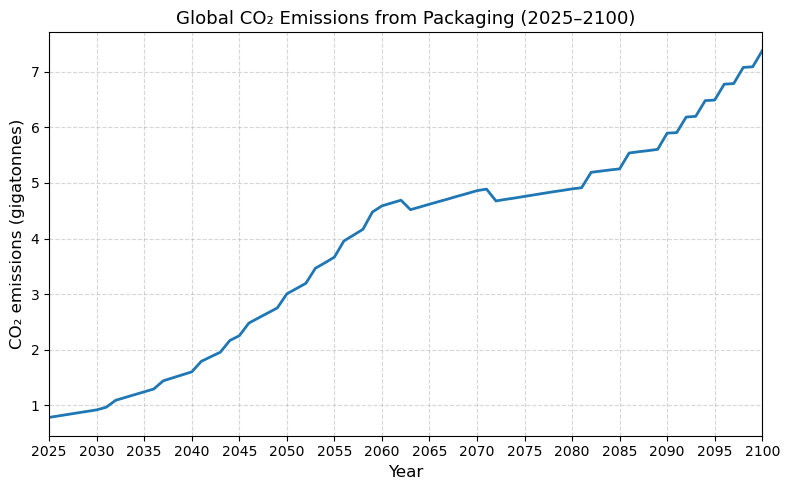

In [88]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Read the CO2 results
co2_by_year_df = pd.read_csv("co2_by_year.csv")

# Convert kg → gigatonnes (1 Gt = 1e12 kg)
co2_by_year_df["CO2_Gt"] = co2_by_year_df["co2_sum"] / 1e12

# Plot (line only, 5-year intervals)
plt.figure(figsize=(8,5))
plt.plot(co2_by_year_df["year"], co2_by_year_df["CO2_Gt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO₂ emissions (gigatonnes)", fontsize=12)
plt.title("Global CO₂ Emissions from Packaging (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()
plt.show()

## Plastic packaging stocks in the ocean

In [93]:
import numpy as np
import pandas as pd

# --- Inputs assumed available ---
# results: list of dicts with keys {"year","g_vector",...}
# B_index_df: has columns ["index","flow name","flow category"] aligned to rows of B

# --- Load flow lists and degradation constants ---
map_flows_df = pd.read_csv("data/MaP.csv")                         # column: "flow name"
k_df         = pd.read_csv("data/fragmentation_cons_yearly.csv")   # columns: "Flow", "fragmentation constant"

# Build: flow_name -> k  (default to 0 if not present)
k_map = {str(r["Flow"]): float(r["fragmentation constant"]) for _, r in k_df.iterrows()}

# Find B row indices for each MaP flow (group by flow name; keep all matches)
flow_to_bidx = {}
for fname in map_flows_df["flow name"].astype(str).unique():
    idxs = B_index_df.loc[B_index_df["flow name"].astype(str) == fname, "index"].astype(int).to_numpy()
    if idxs.size > 0:
        flow_to_bidx[fname] = idxs

if not flow_to_bidx:
    raise ValueError("No MaP flow rows from MaP.csv were found in B_index_df['flow name'].")

# Prepare iteration over years (sorted)
years_sorted = sorted(int(r["year"]) for r in results)
# Per-flow stock state at previous year (initialize to 0 at 2024)
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}

rows = []   # to collect yearly totals and per-flow stocks if desired

for y in years_sorted:
    # get g for this year
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)

    # update each flow's stock with its own k and A_y (kg/year)
    stock_now = {}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))  # generated macroplastic for this flow in year y
        stock_now[fname] = stock_prev[fname] * np.exp(-k) + A_y

    # total MaP stock this year
    total_map = float(np.sum(list(stock_now.values())))

    rows.append({"year": y, "MaP_stock_kg": total_map})
    # carry state
    stock_prev = stock_now

# Save total stock by year
map_stock_df = pd.DataFrame(rows).sort_values("year")
map_stock_df.to_csv("macroplastic_stock_by_year.csv", index=False)

# (Optional) also save per-flow stocks for debugging/analysis
perflow_rows = []
# replay quickly to materialize per-flow time series
stock_prev = {fname: 0.0 for fname in flow_to_bidx.keys()}
for y in years_sorted:
    g = next(r["g_vector"] for r in results if int(r["year"]) == y)
    row = {"year": y}
    for fname, bidx in flow_to_bidx.items():
        k = float(k_map.get(fname, 0.0))
        A_y = float(np.nansum(g[bidx]))
        stock_prev[fname] = stock_prev[fname] * np.exp(-k) + A_y
        row[fname] = stock_prev[fname]
    perflow_rows.append(row)

pd.DataFrame(perflow_rows).to_csv("macroplastic_stock_per_flow_by_year.csv", index=False)

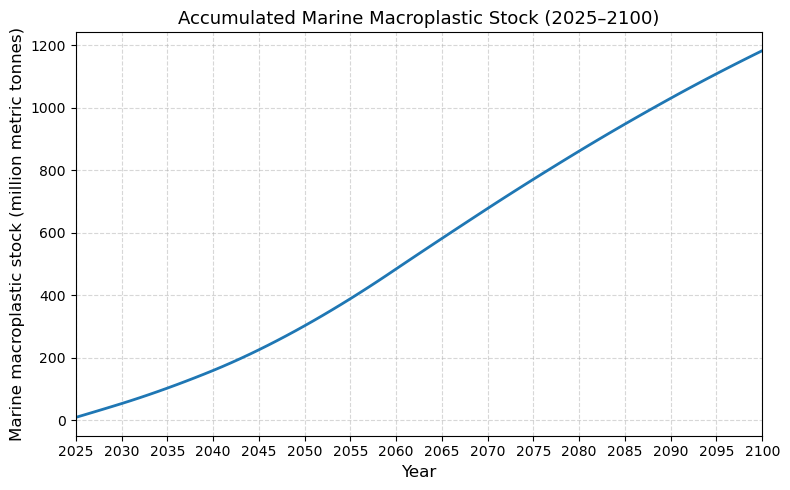

In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the macroplastic stock results
map_stock_df = pd.read_csv("macroplastic_stock_by_year.csv")

# Convert kg → million metric tonnes (1 Mt = 1e9 kg)
map_stock_df["MaP_stock_Mt"] = map_stock_df["MaP_stock_kg"] / 1e9

# Plot
plt.figure(figsize=(8,5))
plt.plot(map_stock_df["year"], map_stock_df["MaP_stock_Mt"], linewidth=2)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Marine macroplastic stock (million metric tonnes)", fontsize=12)
plt.title("Accumulated Marine Macroplastic Stock (2025–2100)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(2025, 2100)
plt.xticks(np.arange(2025, 2101, 5))
plt.tight_layout()
plt.show()